In [43]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import tensorflow as tf

from rembg import remove
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tqdm.notebook import tqdm

seed = 1234

## Data Prep

### Read in Data

In [2]:
# Loading training, testing, and validation directories
train_dir = 'C:/Ubuntu_files/w281/project/Train'
test_dir = 'C:/Ubuntu_files/w281/project/Test'
val_dir = 'C:/Ubuntu_files/w281/project/Validation'

In [3]:
train = tf.keras.utils.image_dataset_from_directory(
    train_dir,  # Directory where the Training images are located
    labels = 'inferred', # Classes will be inferred according to the structure of the directory
    label_mode = 'int',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    # Number of processed samples before updating the model's weights
    image_size = (256, 256), # Defining a fixed dimension for all images
    shuffle = False,  # Shuffling data
    seed = seed,  # Random seed for shuffling and transformations
    validation_split = 0, # We don't need to create a validation set from the training set
    crop_to_aspect_ratio = True # Resize images without aspect ratio distortion
)

Found 1322 files belonging to 3 classes.


In [4]:
test = tf.keras.utils.image_dataset_from_directory(
    test_dir,  
    labels = 'inferred', 
    label_mode = 'int',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256), 
    shuffle = False,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 150 files belonging to 3 classes.


In [5]:
validation = tf.keras.utils.image_dataset_from_directory(
    val_dir,  
    labels = 'inferred', 
    label_mode = 'int',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256),
    shuffle = False,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 60 files belonging to 3 classes.


### Process Data

In [6]:
train_images = np.concatenate([np.round(x.numpy()).astype(np.uint8) for x, _ in train]) #rembg requires uint8 dtype
train_labels = np.concatenate([y.numpy() for _, y in train])

val_images = np.concatenate([np.round(x.numpy()).astype(np.uint8) for x, _ in validation]) #rembg requires uint8 dtype
val_labels = np.concatenate([y.numpy() for _, y in validation])

test_images = np.concatenate([np.round(x.numpy()).astype(np.uint8) for x, _ in test]) #rembg requires uint8 dtype
test_labels = np.concatenate([y.numpy() for _, y in test])

In [7]:
train_images_processed = np.stack([np.array(remove(image))[:, :, :3] for image in tqdm(train_images)]) #remove alpha channel

  0%|          | 0/1322 [00:00<?, ?it/s]

In [8]:
val_images_processed = np.stack([np.array(remove(image))[:, :, :3] for image in tqdm(val_images)]) #remove alpha channel

  0%|          | 0/60 [00:00<?, ?it/s]

In [9]:
test_images_processed = np.stack([np.array(remove(image))[:, :, :3] for image in tqdm(test_images)]) #remove alpha channel

  0%|          | 0/150 [00:00<?, ?it/s]

## Feature Extraction

### Blob Count and Blob Area

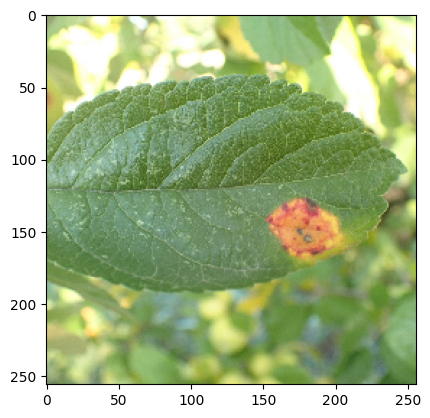

In [10]:
plt.imshow(train_images[1296])

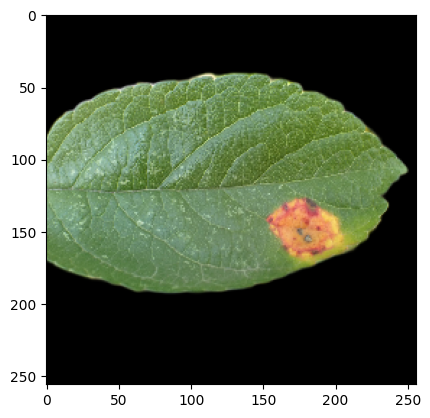

In [11]:
plt.imshow(train_images_processed[1296])

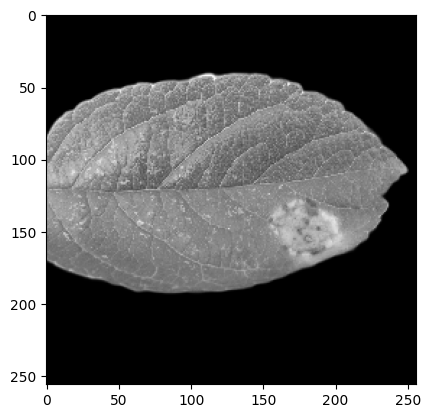

In [12]:
plt.imshow(cv2.cvtColor(train_images_processed[1296], cv2.COLOR_RGB2GRAY), cmap='gray')

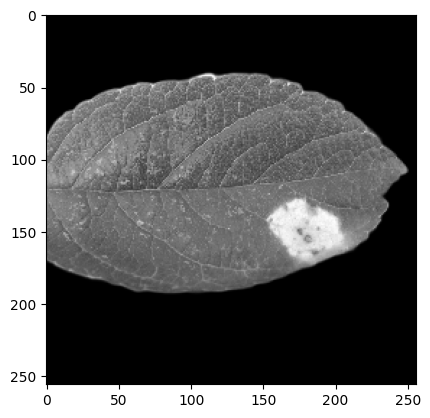

In [13]:
plt.imshow(train_images_processed[1296][:, :, 0], cmap='gray')

95


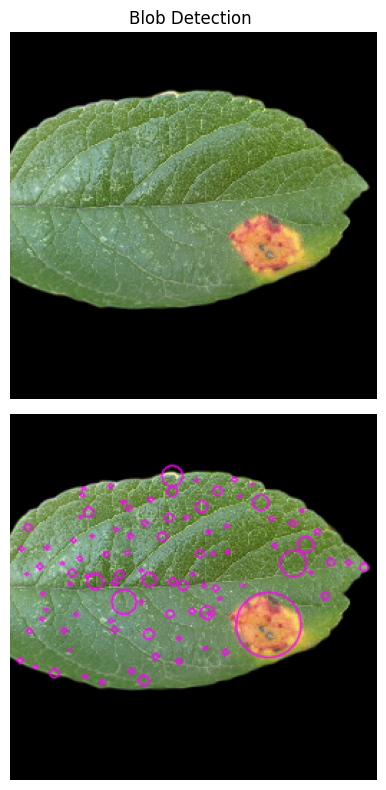

In [14]:
img = train_images_processed[1296].copy()

gray_img = img[:, :, 0]

# Setup SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Example parameter tuning (adjust as needed for your blobs)
params.filterByColor = True
params.blobColor = 255           # Use 0 for dark blobs, 255 for light blobs
params.filterByArea = True
params.minArea = 1              # minimum area of blob
params.maxArea = 5000            # maximum area of blob
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

detector = cv2.SimpleBlobDetector_create(params)
blobs = detector.detect(gray_img)
print(len(blobs))

output = img.copy()
output_with_blobs = cv2.drawKeypoints(
    output,
    blobs,
    np.array([]),
    (255,0,255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)


fig, axs = plt.subplots(2, 1, figsize=(12,8))
axs[0].set_title("Blob Detection ")
axs[0].imshow(img)
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(output_with_blobs, cv2.COLOR_BGR2RGB))
axs[1].imshow(output_with_blobs)
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [15]:
def count_blobs(images, params):
    blob_counts = []
    blob_areas = []
    
    # Create the detector
    detector = cv2.SimpleBlobDetector_create(params)

    for i in range(len(images)):
        img = images[i].copy()

        #gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray_img = img[:, :, 0]

        # Detect blobs
        blobs = detector.detect(gray_img)

        blob_count = len(blobs)
        total_area = 0

        if blobs is not None:
            for blob in blobs:
                total_area += np.pi * ((blob.size / 2) ** 2) #blob.size is blob diameter
                
        blob_counts.append(blob_count)
        blob_areas.append(total_area)
        
    return np.array(blob_counts), np.array(blob_areas)

In [16]:
# Setup SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Example parameter tuning (adjust as needed for your blobs)
params.filterByColor = True
params.blobColor = 255           # Use 0 for dark blobs, 255 for light blobs
params.filterByArea = True
params.minArea = 1              # minimum area of blob
params.maxArea = 5000            # maximum area of blob
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

train_blobs, train_blob_area = count_blobs(train_images_processed, params)
val_blobs, val_blob_area = count_blobs(val_images_processed, params)
test_blobs, test_blob_area = count_blobs(test_images_processed, params)

In [17]:
# def count_blobs(images, params, soft_percentile, hard_percentile):
#     blob_counts = []
#     blob_areas = []
    
#     # Create the detector
#     detector = cv2.SimpleBlobDetector_create(params)

#     for i in range(len(images)):
#         img = images[i].copy()

#         gray_img = img[:, :, 0]
#         flat = gray_img.flatten()

#         threshold = np.quantile(flat, soft_percentile)
#         abs_threshold = hard_percentile * 255

#         rounded_gray_image = np.where((gray_img >= threshold) & (gray_img >= abs_threshold), 255, 0).astype(np.uint8)

#         # Detect blobs
#         blobs = detector.detect(rounded_gray_image)

#         blob_count = len(blobs)
#         total_area = 0

#         if blobs is not None:
#             for blob in blobs:
#                 total_area += np.pi * ((blob.size / 2) ** 2) #blob.size is blob diameter
                
#         blob_counts.append(blob_count)
#         blob_areas.append(total_area)
        
#     return np.array(blob_counts), np.array(blob_areas)

In [18]:
# # Setup SimpleBlobDetector parameters
# params = cv2.SimpleBlobDetector_Params()

# # Example parameter tuning (adjust as needed for your blobs)
# params.filterByColor = True
# params.blobColor = 255           # Use 0 for dark blobs, 255 for light blobs
# params.filterByArea = True
# params.minArea = 1              # minimum area of blob
# params.maxArea = 5000            # maximum area of blob
# params.filterByCircularity = False
# params.filterByConvexity = False
# params.filterByInertia = False

# train_blobs, train_blob_area = count_blobs(train_images_processed, params, soft_percentile=0.99, hard_percentile=0.9)
# val_blobs, val_blob_area = count_blobs(val_images_processed, params, soft_percentile=0.99, hard_percentile=0.9)
# test_blobs, test_blob_area = count_blobs(test_images_processed, params, soft_percentile=0.99, hard_percentile=0.9)

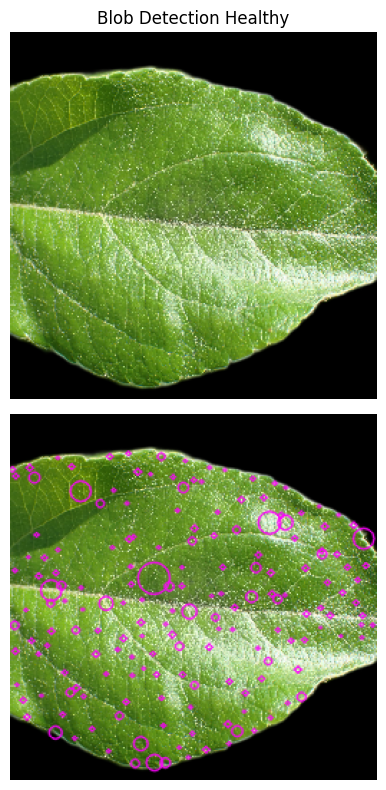

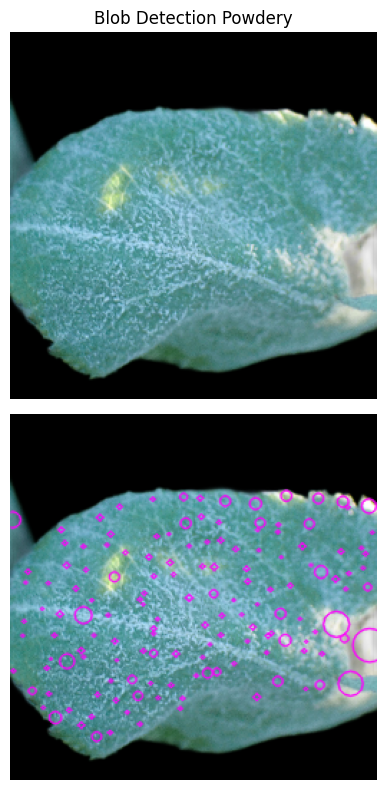

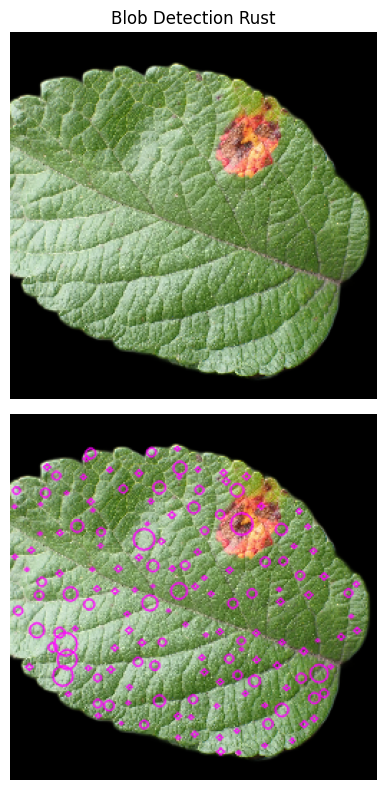

In [19]:
for i, label in enumerate(['Healthy', 'Powdery', 'Rust']):
    filt_data = train_blobs[train_labels == i]
    filt_images = train_images_processed[train_labels == i]

    #plot case with most circles per class
    image = filt_images[np.argmax(filt_data)].copy() #find max count image

    #gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_img = image[:, :, 0]

    # Detect blobs (keypoints)
    detector = cv2.SimpleBlobDetector_create(params)

    #blobs = detector.detect(rounded_gray_image)
    blobs = detector.detect(gray_img)

    output = image.copy()
    output_with_blobs = cv2.drawKeypoints(
        output,
        blobs,
        np.array([]),
        (255,0,255),
        cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    

    fig, axs = plt.subplots(2, 1, figsize=(12,8))
    axs[0].set_title("Blob Detection " + label)
    axs[0].imshow(image)
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(output_with_blobs, cv2.COLOR_BGR2RGB))
    axs[1].imshow(output_with_blobs)
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

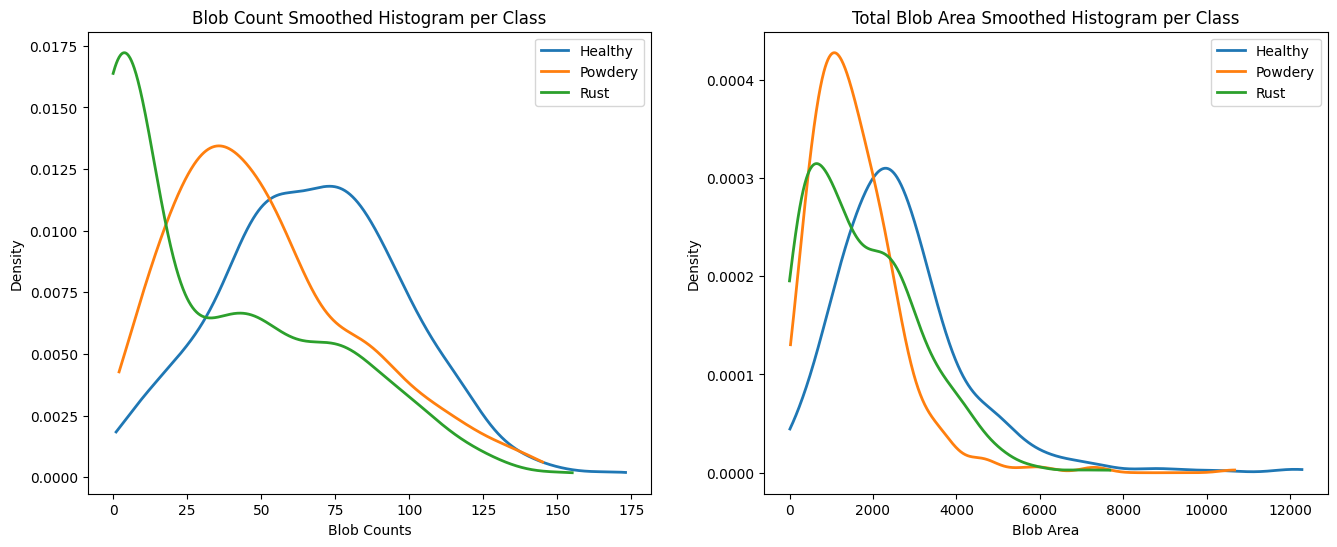

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))
axs[0].set_title('Blob Count Smoothed Histogram per Class')
axs[0].set_xlabel('Blob Counts')
axs[0].set_ylabel('Density')

axs[1].set_title('Total Blob Area Smoothed Histogram per Class')
axs[1].set_xlabel('Blob Area')
axs[1].set_ylabel('Density')

for i, label in enumerate(['Healthy', 'Powdery', 'Rust']):
    class_blobs = train_blobs[train_labels == i]
    class_areas = train_blob_area[train_labels == i]

    # Create an array of x-values for the smooth curve
    blob_x = np.linspace(class_blobs.min(), class_blobs.max(), 1000)
    area_x = np.linspace(class_areas.min(), class_areas.max(), 1000)

    # Calculate the KDE
    blob_kde = stats.gaussian_kde(class_blobs)
    area_kde = stats.gaussian_kde(class_areas)

    axs[0].plot(blob_x, blob_kde(blob_x), linewidth=2, label=label)
    axs[1].plot(area_x, area_kde(area_x), linewidth=2, label=label)

axs[0].legend()
axs[1].legend()
plt.show()

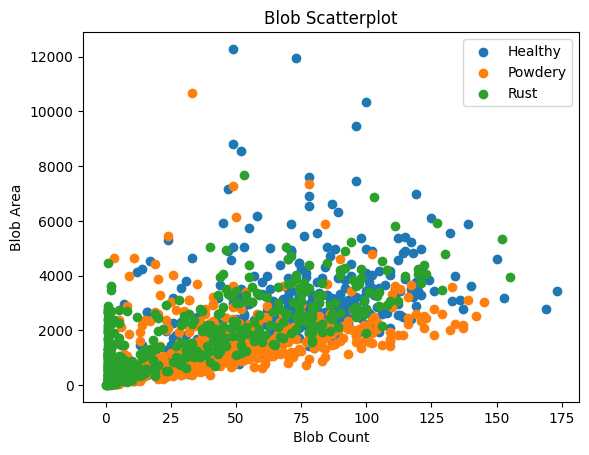

In [21]:
for i, label in enumerate(['Healthy', 'Powdery', 'Rust']):
    class_blobs = train_blobs[train_labels == i]
    class_areas = train_blob_area[train_labels == i]

    plt.scatter(class_blobs, class_areas, label=label)

plt.title('Blob Scatterplot')
plt.xlabel('Blob Count')
plt.ylabel('Blob Area')
plt.legend()
plt.show()

### Luminance Histogram

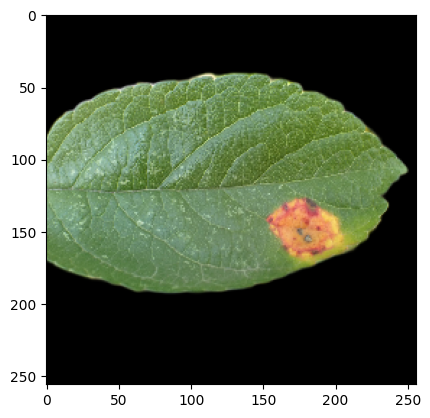

In [22]:
plt.imshow(train_images_processed[1296])

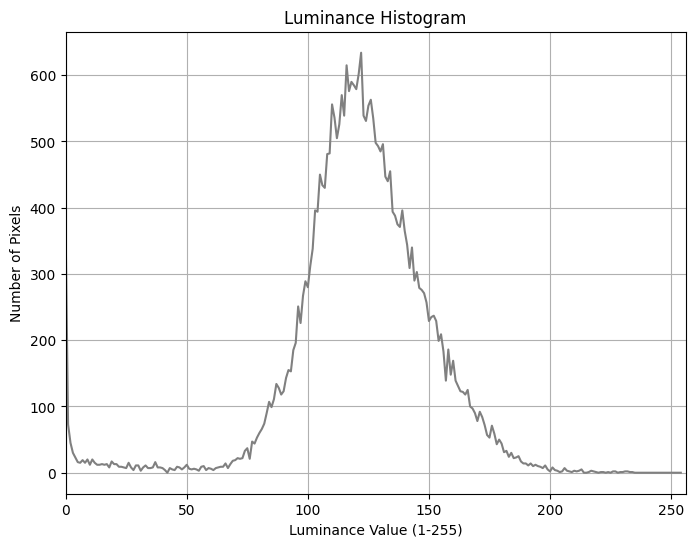

In [23]:
lumin_hist = cv2.calcHist([cv2.cvtColor(train_images_processed[1296], cv2.COLOR_BGR2GRAY)], [0], None, [255], [1, 256])

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.title("Luminance Histogram")
plt.xlabel("Luminance Value (1-255)")
plt.ylabel("Number of Pixels")
plt.plot(lumin_hist, color='gray')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

In [24]:
def luminance(images):
    return np.stack([cv2.calcHist([cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)], [0], None, [255], [1, 256]).flatten().astype(int) for image in images])

In [25]:
train_lumin = luminance(train_images_processed)
val_lumin = luminance(val_images_processed)
test_lumin = luminance(test_images_processed)

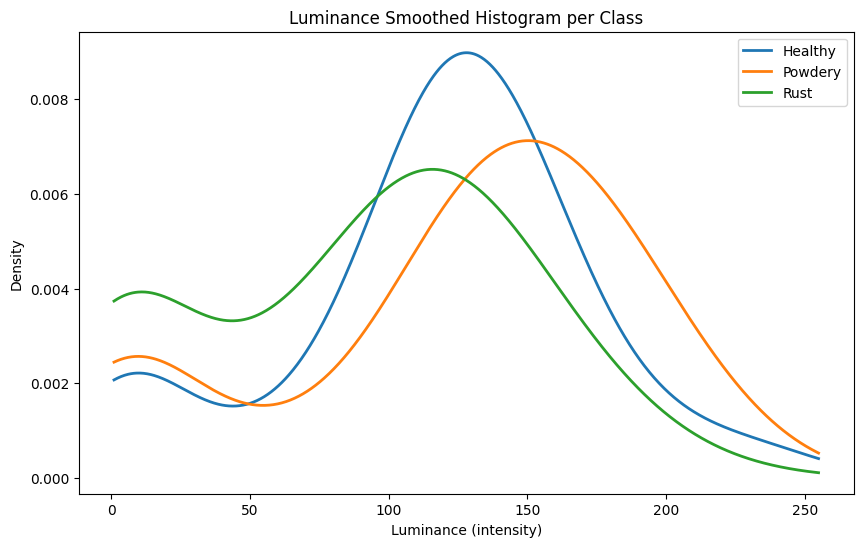

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title('Luminance Smoothed Histogram per Class')
ax.set_xlabel('Luminance (intensity)')
ax.set_ylabel('Density')

class_names = ['Healthy', 'Powdery', 'Rust']

for i, label in enumerate(class_names):
    # Select luminance histograms for this class: shape (n_samples, n_bins)
    class_lumin = train_lumin[train_labels == i]

    if class_lumin.size == 0:
        continue  # just in case

    # Aggregate histograms across images in this class
    hist_sum = class_lumin.sum(axis=0)  # shape (n_bins,)

    # Bin centers corresponding to your luminance() definition
    # (you used [255] bins in range [1, 256], so centers are 1..255)
    bin_centers = np.arange(1, 256)

    # KDE over bin centers, weighted by counts in each bin
    kde = stats.gaussian_kde(bin_centers, weights=hist_sum)

    # Smooth curve grid
    x = np.linspace(1, 255, 1000)
    ax.plot(x, kde(x), linewidth=2, label=label)

ax.legend()
plt.show()

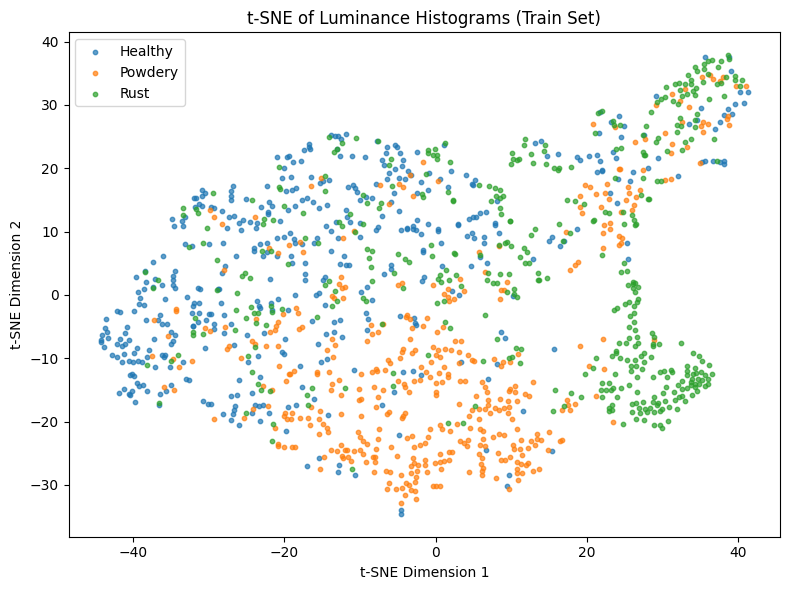

In [27]:
tsne = TSNE(
    n_components=2,
    perplexity=30,      # tune if needed (5–50 often reasonable)
    learning_rate='auto',
    init='random',
    random_state=seed
)
X_embedded = tsne.fit_transform(train_lumin)  # shape: (n_samples, 2)

# Plot
plt.figure(figsize=(8, 6))
class_names = ['Healthy', 'Powdery', 'Rust']

for i, name in enumerate(class_names):
    mask = (train_labels == i)
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        s=10,
        alpha=0.7,
        label=name
    )

plt.title('t-SNE of Luminance Histograms (Train Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

### ResNet (CNN Feature Vector)

In [44]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,      # remove classification head
    pooling='avg',          # global average pooling → 2048-length vector
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [45]:
def extract_resnet_features(images, batch_size=32):
    """
    images: NumPy array of shape (N, H, W, 3), values in [0, 255] or [0, 1]
    returns: NumPy array of shape (N, 2048) with one feature vector per image
    """
    # Convert to float32
    images = images.astype("float32")

    # Resize to ResNet's expected input size (224x224)
    images_resized = tf.image.resize(images, (224, 224))

    # Apply ResNet preprocessing (mean subtraction, etc.)
    images_preprocessed = preprocess_input(images_resized)

    # Run through ResNet to get features
    features = resnet_base.predict(images_preprocessed, batch_size=batch_size, verbose=1)

    # features is already a NumPy array of shape (N, 2048)
    return features

In [46]:
train_cnn_features = extract_resnet_features(train_images, batch_size=32)
val_cnn_features = extract_resnet_features(val_images, batch_size=32)
test_cnn_features = extract_resnet_features(test_images, batch_size=32)

42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 447ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 379ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step


## Results

### Build Classifiers

In [28]:
# Baseline toy classifier, feeding in grayscale images directly to a LR classifier

train_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in train_images_processed])
val_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in val_images_processed])
test_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in test_images_processed])

# Flatten each image to shape (H*W,)
X_train_flat = train_gray.reshape(train_gray.shape[0], -1)
X_val_flat = val_gray.reshape(val_gray.shape[0], -1)

log_reg_flat = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

log_reg_flat.fit(X_train_flat, train_labels)

val_pred_flat = log_reg_flat.predict(X_val_flat)

print(classification_report(val_labels, val_pred_flat))

c:\anaconda3\envs\w281\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.38      0.40      0.39        20
           2       0.28      0.25      0.26        20

    accuracy                           0.43        60
   macro avg       0.43      0.43      0.43        60
weighted avg       0.43      0.43      0.43        60



In [54]:
# Untuned LR

X_train = np.column_stack([train_blobs, train_blob_area, train_lumin, train_cnn_features])
X_val = np.column_stack([val_blobs, val_blob_area, val_lumin, val_cnn_features])
X_test = np.column_stack([test_blobs, test_blob_area, test_lumin, test_cnn_features])

log_reg = LogisticRegression(
    multi_class='multinomial',  # proper multiclass softmax
    solver='lbfgs',
    max_iter=1000
)

# Fit on 2D feature matrix
log_reg.fit(X_train, train_labels)

# Validate
val_pred_lr = log_reg.predict(X_val)
print(classification_report(val_labels, val_pred_lr))

c:\anaconda3\envs\w281\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.81      0.85      0.83        20
           1       0.95      0.95      0.95        20
           2       0.89      0.85      0.87        20

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



c:\anaconda3\envs\w281\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
# Tuned LR

# Base model (we’ll tune C, maybe class_weight)
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',   # supports multinomial + l2
    max_iter=1000
)

# Hyperparameter grid to search over
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"]
}

# Grid search with 5-fold CV, optimizing accuracy
grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,        # use all cores
    verbose=1
)

# Fit grid search on training data
grid.fit(X_train, train_labels)

print("Best hyperparameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

# Use the best model to predict on validation set
best_log_reg = grid.best_estimator_
val_pred_lr = best_log_reg.predict(X_val)

# Evaluation on validation set
print(classification_report(val_labels, val_pred_lr))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\anaconda3\envs\w281\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best hyperparameters: {'C': 10, 'class_weight': 'balanced'}
Best CV accuracy: 0.8457
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        20
           1       0.95      0.95      0.95        20
           2       0.85      0.85      0.85        20

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



c:\anaconda3\envs\w281\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
# Untuned SVC

svc = SVC(
    kernel='rbf',         # or 'linear', 'poly', 'sigmoid'
    C=1.0,                # regularization strength
    gamma='scale',        # kernel coefficient
    probability=True,     # enables predict_proba (needed for ROC curves)
    decision_function_shape='ovr'  # One-vs-Rest multiclass scheme
)

# Train the model
svc.fit(X_train, train_labels)

# Validate
val_pred_svc = svc.predict(X_val)

# Print report
print(classification_report(val_labels, val_pred_svc))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.80      0.80      0.80        20
           2       0.79      0.75      0.77        20

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



In [50]:
# Tuned SVC

svc = SVC(
    kernel='rbf',
    probability=True,              # keep this so we can use predict_proba later
    decision_function_shape='ovr'  # One-vs-Rest
)

# Hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
}

# Grid search with 5-fold cross-validation
grid_svc = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
grid_svc.fit(X_train, train_labels)

print("Best hyperparameters:", grid_svc.best_params_)
print(f"Best CV accuracy: {grid_svc.best_score_:.4f}")

# Use the best-found model
best_svc = grid_svc.best_estimator_

# Validate on hold-out set
val_pred_svc = best_svc.predict(X_val)

print(classification_report(val_labels, val_pred_svc))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters: {'C': 10, 'gamma': 'scale'}
Best CV accuracy: 0.7390
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        20
           1       0.73      0.80      0.76        20
           2       0.82      0.70      0.76        20

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60



In [52]:
# Untuned RF

rf = RandomForestClassifier(
    n_estimators=200,    # number of trees
    max_depth=None,     # allow trees to grow fully
    random_state=seed,    # reproducible results
    class_weight=None   # or 'balanced' if your dataset is imbalanced
)

# Train the model
rf.fit(X_train, train_labels)

# Validate
val_pred_rf = rf.predict(X_val)

# Print report
print(classification_report(val_labels, val_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [53]:
# Tuned RF

rf = RandomForestClassifier(
    random_state=seed,
    class_weight=None
)

# Parameter grid for Random Forest
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_rf.fit(X_train, train_labels)

print("Best hyperparameters:", grid_rf.best_params_)
print(f"Best CV accuracy: {grid_rf.best_score_:.4f}")

# Best model
best_rf = grid_rf.best_estimator_

# Validate
val_pred_rf = best_rf.predict(X_val)

# Classification report
print(classification_report(val_labels, val_pred_rf))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV accuracy: 0.9818
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [ ]:
#these results look suspicious so I will break the rules and check against the test set. It's possible that with the small size of the val set that things are still working correctly

test_pred_rf = best_rf.predict(X_test)

# Classification report
print(classification_report(test_labels, test_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           1       1.00      0.90      0.95        50
           2       0.96      1.00      0.98        50

    accuracy                           0.95       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.95      0.95       150



### Visualizations

#### Confusion Matrices

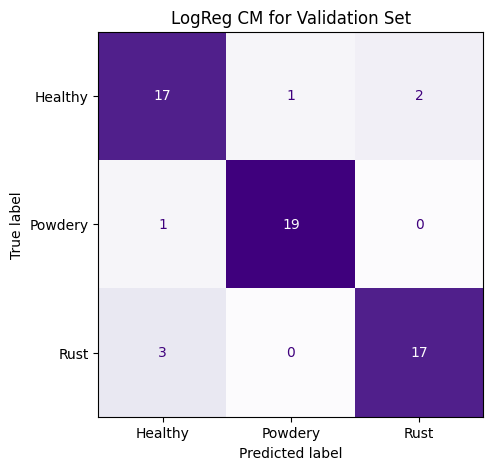

In [56]:
class_names = ["Healthy", "Powdery", "Rust"]
cm = confusion_matrix(val_labels, val_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Purples", values_format="d", colorbar=False)
plt.title("LogReg CM for Validation Set")
plt.show()

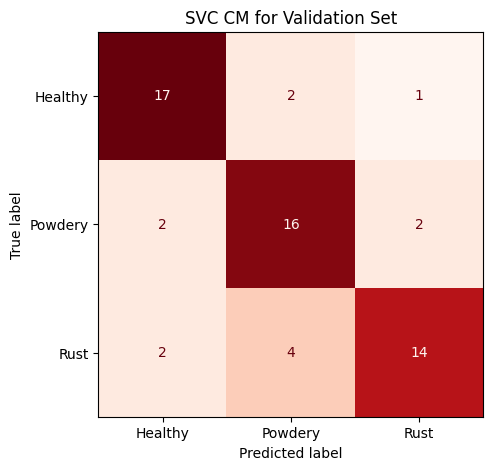

In [57]:
class_names = ["Healthy", "Powdery", "Rust"]
cm = confusion_matrix(val_labels, val_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Reds", values_format="d", colorbar=False)
plt.title("SVC CM for Validation Set")
plt.show()

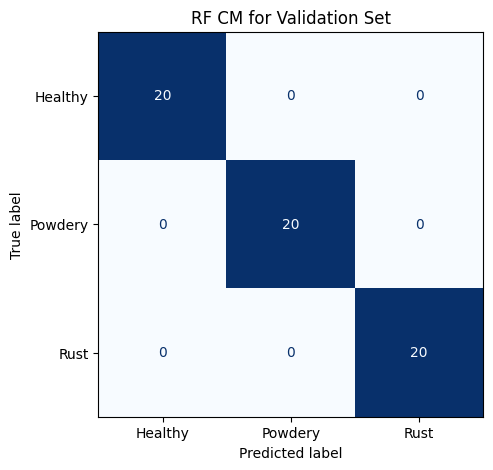

In [58]:
class_names = ["Healthy", "Powdery", "Rust"]
cm = confusion_matrix(val_labels, val_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("RF CM for Validation Set")
plt.show()

#### ROC Curves

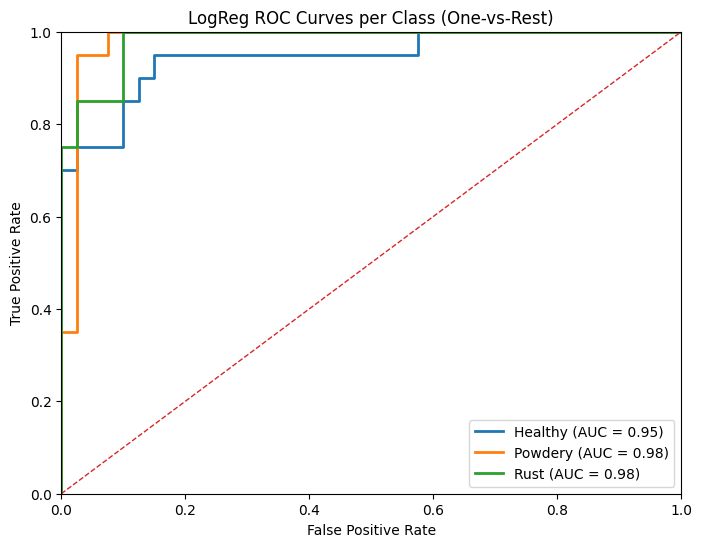

AUC for class 0: 0.9463
AUC for class 1: 0.9813
AUC for class 2: 0.9825


In [59]:
y_score = best_log_reg.predict_proba(X_val)  # shape: (n_samples, n_classes)

# Binarize the true labels: one-vs-rest
classes = best_log_reg.classes_               # ensures same order as columns of y_score
y_true_bin = label_binarize(val_labels, classes=classes)  # shape: (n_samples, n_classes)

# Prepare plot
plt.figure(figsize=(8, 6))

auc_per_class = {}

for i, cls in enumerate(classes):
    # ROC for this class vs rest
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc

    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LogReg ROC Curves per Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

# Print AUC per class
for cls, cls_auc in auc_per_class.items():
    print(f"AUC for class {cls}: {cls_auc:.4f}")

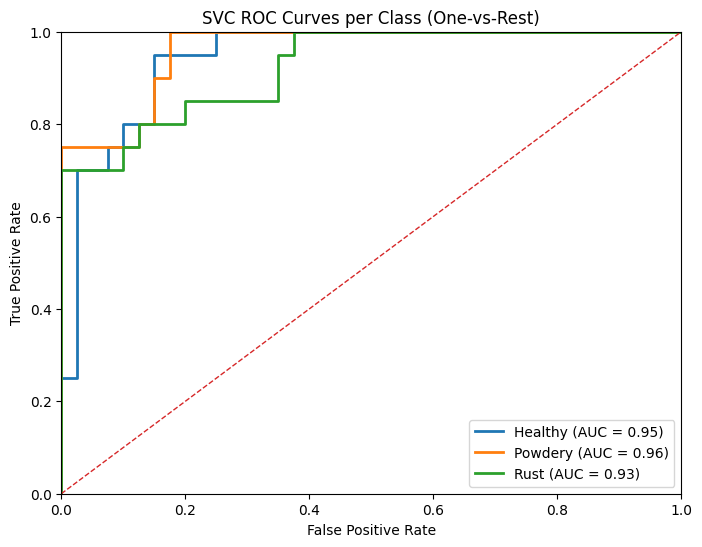

AUC for class 0: 0.9450
AUC for class 1: 0.9612
AUC for class 2: 0.9250


In [60]:
y_score = best_svc.predict_proba(X_val)  # shape: (n_samples, n_classes)

# Binarize the true labels: one-vs-rest
classes = best_svc.classes_               # ensures same order as columns of y_score
y_true_bin = label_binarize(val_labels, classes=classes)  # shape: (n_samples, n_classes)

# Prepare plot
plt.figure(figsize=(8, 6))

auc_per_class = {}

for i, cls in enumerate(classes):
    # ROC for this class vs rest
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc

    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVC ROC Curves per Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

# Print AUC per class
for cls, cls_auc in auc_per_class.items():
    print(f"AUC for class {cls}: {cls_auc:.4f}")

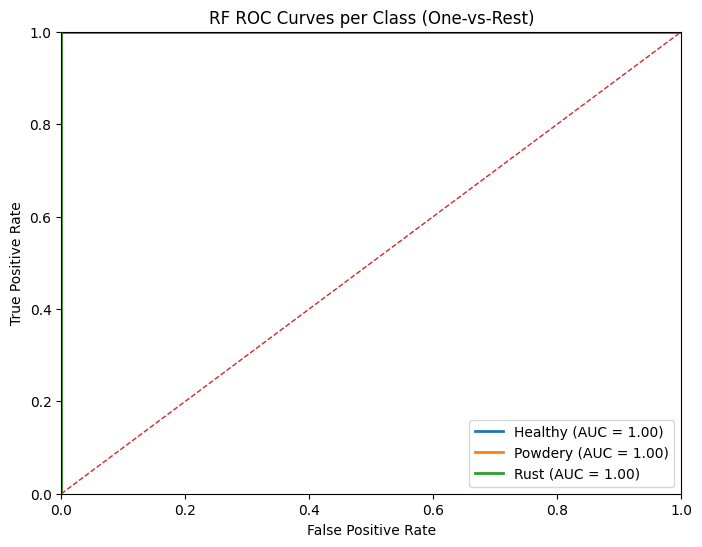

AUC for class 0: 1.0000
AUC for class 1: 1.0000
AUC for class 2: 1.0000


In [61]:
y_score = best_rf.predict_proba(X_val)  # shape: (n_samples, n_classes)

# Binarize the true labels: one-vs-rest
classes = best_rf.classes_               # ensures same order as columns of y_score
y_true_bin = label_binarize(val_labels, classes=classes)  # shape: (n_samples, n_classes)

# Prepare plot
plt.figure(figsize=(8, 6))

auc_per_class = {}

for i, cls in enumerate(classes):
    # ROC for this class vs rest
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc

    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RF ROC Curves per Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

# Print AUC per class
for cls, cls_auc in auc_per_class.items():
    print(f"AUC for class {cls}: {cls_auc:.4f}")

## Final Results

In [41]:
# TBD once everything else is done

In [42]:
# np.savez_compressed("train_blob_counts.npz",
#          IMAGES=train_images_processed,
#          LABELS=train_labels,
#          BLOB_COUNT=train_blobs)

# np.savez_compressed("val_blob_counts.npz",
#          IMAGES=val_images_processed,
#          LABELS=val_labels,
#          BLOB_COUNT=val_blobs)

# np.savez_compressed("test_blob_counts.npz",
#          IMAGES=test_images_processed,
#          LABELS=test_labels,
#          BLOB_COUNT=test_blobs)